# 01 - Khám Phá Dữ Liệu (EDA)

**Mục tiêu:**
- Mô tả dữ liệu và data dictionary
- Thống kê mô tả, phân phối
- Phân tích missing values
- Phân tích tương quan
- Phân tích target

In [ ]:
import sys
sys.path.insert(0, '..')
import os
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1.1 Load dữ liệu

In [ ]:
from src.data.loader import load_raw_data, check_schema, get_data_summary, print_data_dictionary

df = load_raw_data()

✅ Loaded data from: D:\Data_Mining\data\raw\heart.csv
   Shape: 920 rows × 16 columns


In [ ]:
# Data Dictionary
print_data_dictionary()

DATA DICTIONARY - Heart Disease UCI Dataset
  id           : ID bệnh nhân
  age          : Tuổi (năm)
  sex          : Giới tính (Male/Female)
  dataset      : Nguồn dữ liệu (Cleveland, Hungary, Switzerland, VA Long Beach)
  cp           : Loại đau ngực (typical angina, atypical angina, non-anginal, asymptomatic)
  trestbps     : Huyết áp lúc nghỉ (mm Hg)
  chol         : Cholesterol huyết thanh (mg/dl)
  fbs          : Đường huyết lúc đói > 120 mg/dl (True/False)
  restecg      : Kết quả điện tâm đồ lúc nghỉ (normal, st-t abnormality, lv hypertrophy)
  thalch       : Nhịp tim tối đa đạt được (bpm)
  exang        : Đau thắt ngực khi vận động (True/False)
  oldpeak      : ST depression do vận động so với nghỉ
  slope        : Độ dốc đoạn ST đỉnh (upsloping, flat, downsloping)
  ca           : Số mạch máu chính được nhuộm bằng fluoroscopy (0-3)
  thal         : Thalassemia (normal, fixed defect, reversable defect)
  num          : Chẩn đoán bệnh tim (0: không bệnh, 1-4: mức độ bệnh)


In [ ]:
# Kiểm tra schema
schema = check_schema(df)

✅ Schema check passed - all expected columns present


In [ ]:
# Xem mẫu dữ liệu
df.head(10)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [ ]:
# Thông tin tổng quan
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


## 1.2 Thống kê mô tả

In [ ]:
# Bảng summary
summary = get_data_summary(df)
summary

,dtype,missing,missing_%,unique,sample,min,max,mean
id,int64,0,0.00,920,1,1.0,920.0,460.50
age,int64,0,0.00,50,63,28.0,77.0,53.51
sex,object,0,0.00,2,Male,NaN,NaN,NaN
dataset,object,0,0.00,4,Cleveland,NaN,NaN,NaN
cp,object,0,0.00,4,typical angina,NaN,NaN,NaN
trestbps,float64,59,6.41,61,145.0,0.0,200.0,132.13
chol,float64,30,3.26,217,233.0,0.0,603.0,199.13
fbs,object,90,9.78,2,True,NaN,NaN,NaN
restecg,object,2,0.22,3,lv hypertrophy,NaN,NaN,NaN
thalch,float64,55,5.98,119,150.0,60.0,202.0,137.55


In [ ]:
# Thống kê mô tả cho biến số
df.describe().round(2)

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.00,920.00,861.00,890.00,865.00,858.00,309.00,920.00
mean,460.50,53.51,132.13,199.13,137.55,0.88,0.68,1.00
std,265.73,9.42,19.07,110.78,25.93,1.09,0.94,1.14
min,1.00,28.00,0.00,0.00,60.00,-2.60,0.00,0.00
25%,230.75,47.00,120.00,175.00,120.00,0.00,0.00,0.00
50%,460.50,54.00,130.00,223.00,140.00,0.50,0.00,1.00
75%,690.25,60.00,140.00,268.00,157.00,1.50,1.00,2.00
max,920.00,77.00,200.00,603.00,202.00,6.20,3.00,4.00


In [ ]:
# Thống kê cho biến phân loại
df.describe(include='object')

,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,normal
freq,726,304,496,692,551,528,345,196


## 1.3 Phân tích Missing Values

💾 Saved: outputs/figures\missing_values.png


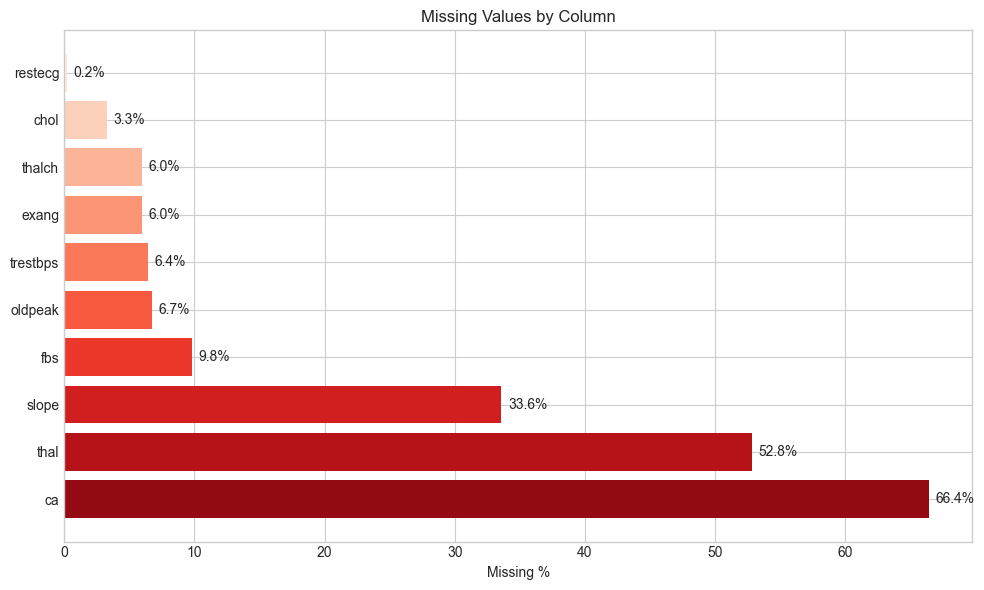

In [ ]:
from src.visualization.plots import plot_missing_values

fig = plot_missing_values(df, save=True)
plt.show()

In [ ]:
# Bảng missing chi tiết
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Percent', ascending=False)
missing_df

,Count,Percent
ca,611,66.41
thal,486,52.83
slope,309,33.59
fbs,90,9.78
oldpeak,62,6.74
trestbps,59,6.41
exang,55,5.98
thalch,55,5.98
chol,30,3.26
restecg,2,0.22


## 1.4 Phân phối Target

In [ ]:
# Phân phối target gốc (multi-class 0-4)
print("Target distribution (original - num):")
print(df['num'].value_counts().sort_index())
print(f"\nBinary: No Disease={( df['num']==0).sum()}, Disease={(df['num']>0).sum()}")

Target distribution (original - num):
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Binary: No Disease=411, Disease=509


💾 Saved: outputs/figures\target_distribution.png


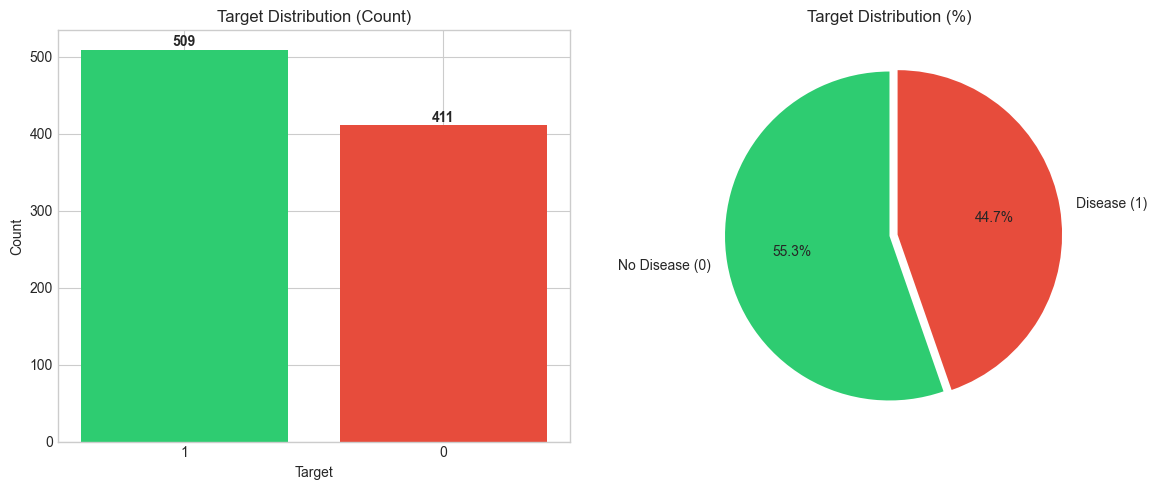

In [ ]:
# Tạo binary target để vẽ
df_temp = df.copy()
df_temp['target'] = (df_temp['num'] > 0).astype(int)

from src.visualization.plots import plot_target_distribution
fig = plot_target_distribution(df_temp, save=True)
plt.show()

## 1.5 Phân phối các biến số

💾 Saved: outputs/figures\numeric_distributions.png


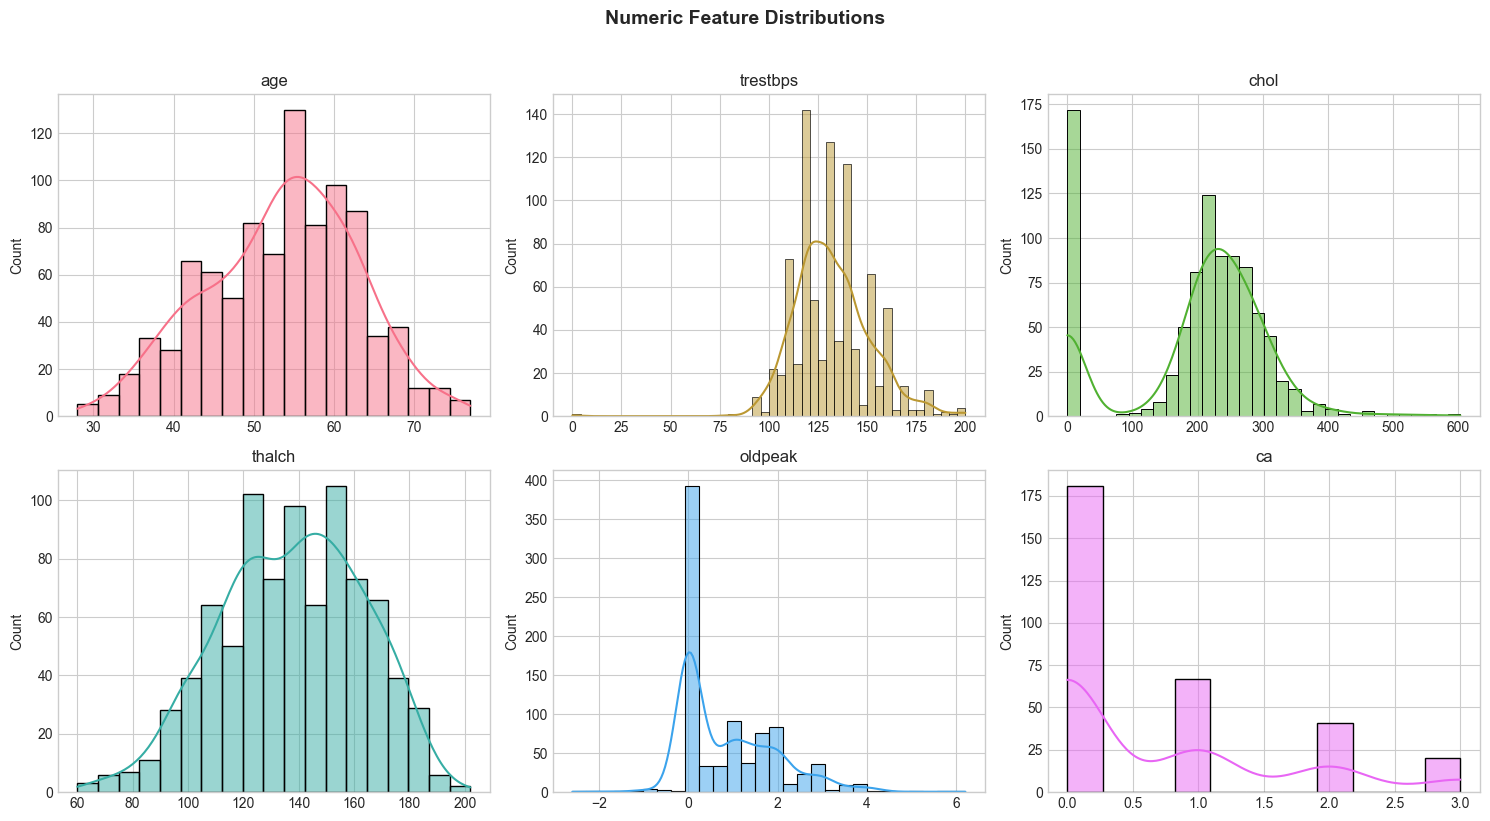

In [ ]:
from src.visualization.plots import plot_numeric_distributions

numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
fig = plot_numeric_distributions(df, cols=numeric_cols, save=True)
plt.show()

## 1.6 Phân phối biến phân loại

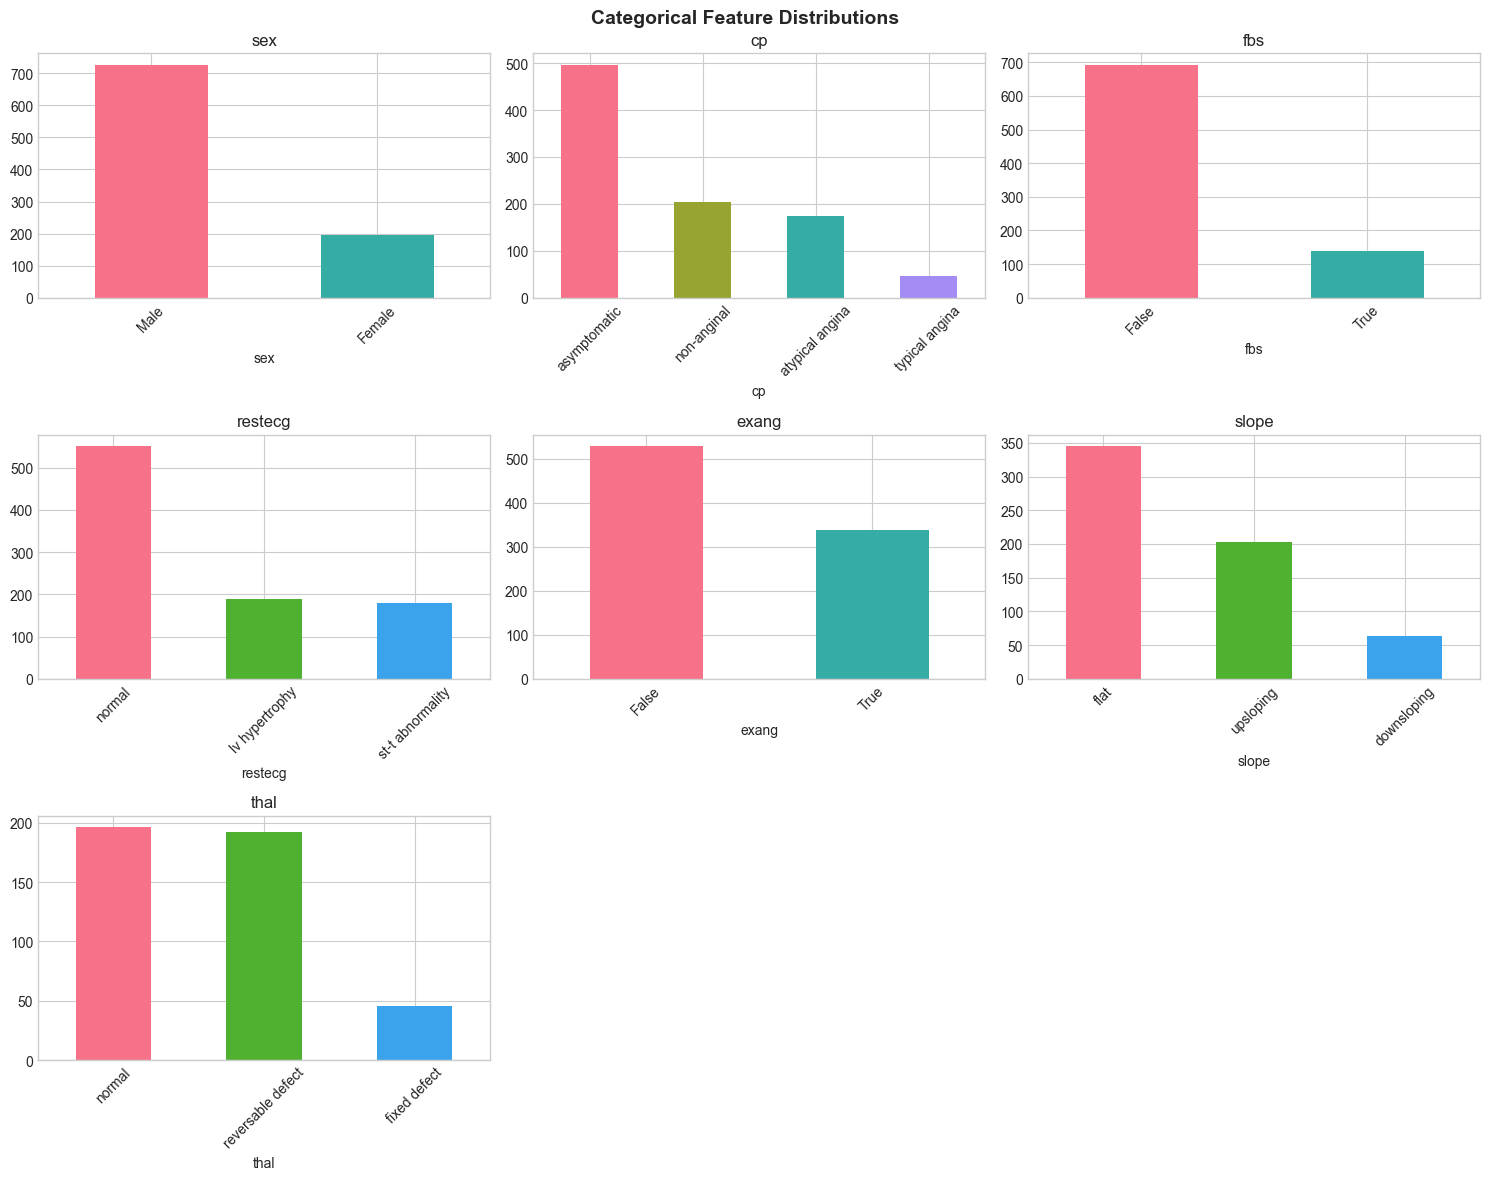

In [ ]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if i < len(axes):
        df[col].value_counts().plot(kind='bar', ax=axes[i], color=sns.color_palette('husl', df[col].nunique()))
        axes[i].set_title(f'{col}')
        axes[i].tick_params(axis='x', rotation=45)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.7 Ma trận tương quan

💾 Saved: outputs/figures\correlation_matrix.png


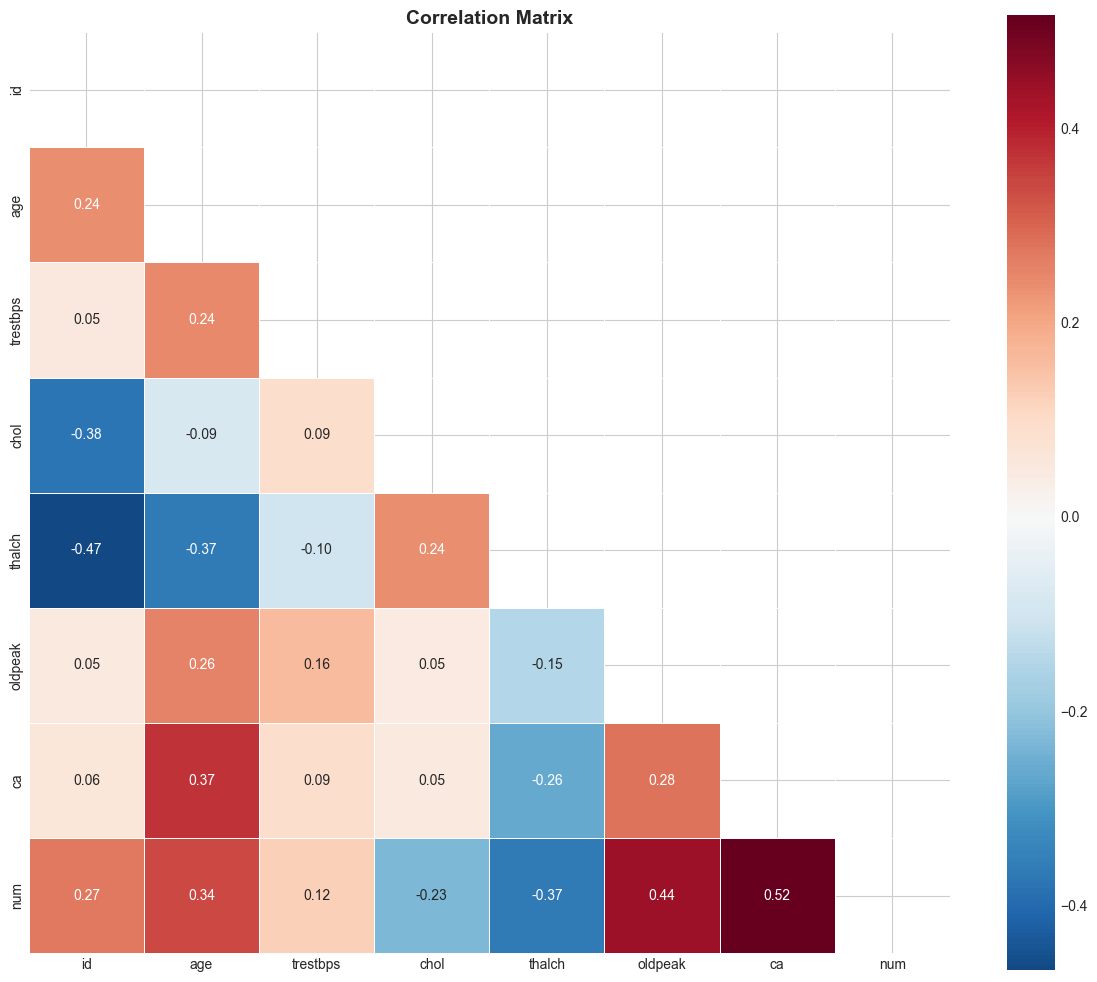

In [ ]:
# Chỉ dùng biến số cho correlation
numeric_df = df.select_dtypes(include='number')

from src.visualization.plots import plot_correlation_matrix
fig = plot_correlation_matrix(numeric_df, save=True)
plt.show()

## 1.8 Biến số theo Target

💾 Saved: outputs/figures\features_vs_target.png


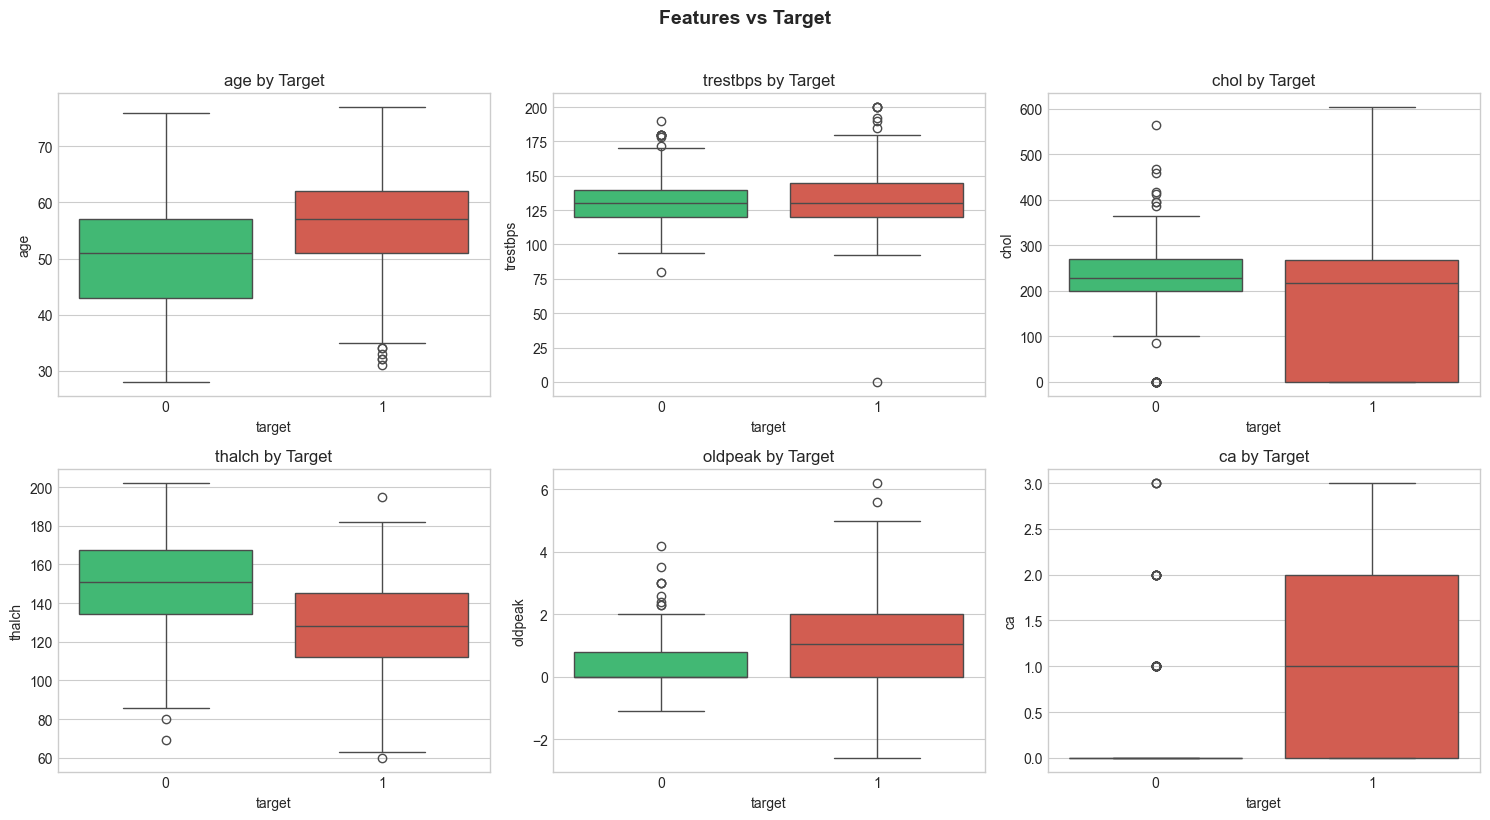

In [ ]:
df_temp = df.copy()
df_temp['target'] = (df_temp['num'] > 0).astype(int)

from src.visualization.plots import plot_features_vs_target
fig = plot_features_vs_target(df_temp, cols=['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca'], save=True)
plt.show()

## 1.9 Biến phân loại theo Target

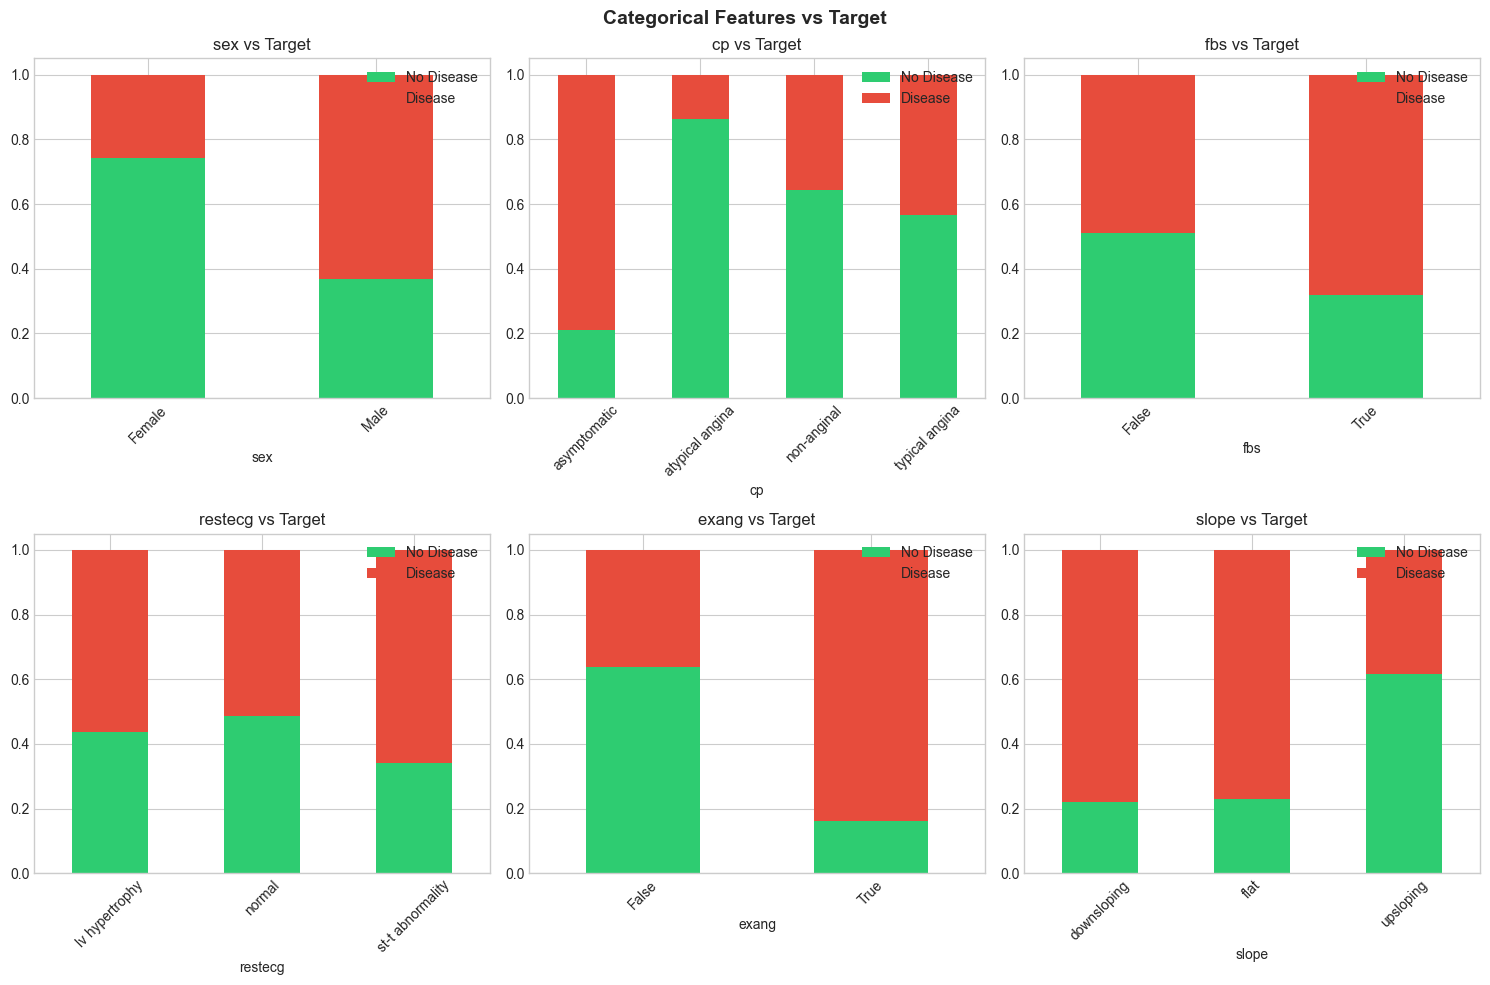

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']):
    ct = pd.crosstab(df[col], df_temp['target'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} vs Target')
    axes[i].legend(['No Disease', 'Disease'])
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/categorical_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.10 Rủi ro & Thách thức

> ⚠️ **Tiêu chí A yêu cầu nêu rủi ro dữ liệu**

### Mất cân bằng lớp (Class Imbalance)
- 411 không bệnh (45%) vs 509 bệnh (55%) → nhẹ, nhưng cần xử lý
- Giải pháp: SMOTE + class_weight='balanced'

### Missing Values nghiêm trọng
- `ca`: 66%, `thal`: 53%, `slope`: 34% → cần chiến lược fill hợp lý
- Drop cột missing > 40% hoặc fill median/mode

### Data Leakage tiềm ẩn
- PHẢI scale SAU khi split train/test
- SMOTE chỉ áp dụng trên train set
- Cross-validation dùng StratifiedKFold để giữ tỷ lệ lớp

### Dữ liệu đa nguồn
- 4 trung tâm y tế khác nhau → phân phối có thể khác biệt
- Cột `dataset` bị drop để tránh bias theo nguồn

In [ ]:
# Phân tích theo nguồn dữ liệu
print("Phân phối target theo nguồn dữ liệu:")
ct = pd.crosstab(df['dataset'], df_temp['target'], normalize='index').round(3)
print(ct)
print("\n→ Tỷ lệ bệnh khác nhau giữa các nguồn: cần cẩn thận khi tổng quát hoá")

Phân phối target theo nguồn dữ liệu:
target             0      1
dataset                    
Cleveland      0.543  0.457
Hungary        0.638  0.362
Switzerland    0.065  0.935
VA Long Beach  0.255  0.745

→ Tỷ lệ bệnh khác nhau giữa các nguồn: cần cẩn thận khi tổng quát hoá


## 1.11 Nhận xét EDA

**Dữ liệu:**
- 920 mẫu, 16 cột (14 features + id + dataset)
- Missing values cao ở `ca` (66%), `thal` (53%), `slope` (34%)
- Target imbalanced nhẹ: 411 no disease vs 509 disease

**Phát hiện chính:**
- Cần xử lý missing values trước khi modeling
- Các biến `cp`, `thalch`, `oldpeak`, `ca` có tương quan mạnh với target
- Cần encoding biến phân loại
- Dữ liệu gộp từ 4 nguồn với tỷ lệ bệnh khác nhau